# Walk-Forward Model Benchmark

Compare fixed linear and tree-model candidates across purged expanding-time folds. All selection windows end before July 2025, because the later test history has already been inspected and must not be reused to claim a new champion.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from pipelines.ml.features import build_event_feature_dataset
from pipelines.ml.model_benchmark import (
    benchmark_to_json,
    run_walk_forward_benchmark,
)

In [2]:
dataset = build_event_feature_dataset(horizon=30, include_topics=True)
benchmark = run_walk_forward_benchmark(dataset)
payload = benchmark_to_json(benchmark)

print(f'Labeled events: {int(dataset.target_available.sum()):,}')
print(f'Candidates: {len(benchmark.candidates)}')
print(f'Walk-forward folds: {len(benchmark.folds)}')

Labeled events: 721
Candidates: 12
Walk-forward folds: 4


## Leakage Audit

Rows whose forward-return label crosses a validation boundary are purged. Future rows after each validation window are excluded rather than treated as training data.

In [3]:
folds = pd.DataFrame(payload['folds'])
folds

,name,validation_start,validation_end,train_rows,validation_rows,purged_rows,overlapping_event_keys,train_targets_cross_validation,validation_targets_cross_end,validation_features_before_start,validation_features_at_or_after_end
0,fold_01,2023-07-01,2024-01-01,247,74,12,0,0,0,0,0
1,fold_02,2024-01-01,2024-07-01,327,74,12,0,0,0,0,0
2,fold_03,2024-07-01,2025-01-01,407,74,12,0,0,0,0,0
3,fold_04,2025-01-01,2025-07-01,487,72,11,0,0,0,0,0


## Model Comparison

Mean fold MAE is the locked selection metric. Directional accuracy and Spearman IC remain diagnostics; they cannot override a failed MAE comparison after results are visible.

In [4]:
columns = [
    'model',
    'family',
    'mean_mae',
    'std_mae',
    'mean_directional_accuracy',
    'pooled_spearman_ic',
]
benchmark.summary[columns].style.format({
    'mean_mae': '{:.4f}',
    'std_mae': '{:.4f}',
    'mean_directional_accuracy': '{:.1%}',
    'pooled_spearman_ic': '{:.3f}',
})

,model,family,mean_mae,std_mae,mean_directional_accuracy,pooled_spearman_ic
0,historical_mean,baseline_mean,0.0650,0.0141,46.0%,-0.010
1,zero_excess,baseline_zero,0.0650,0.0144,47.9%,nan
2,xgboost_registered_shape,xgboost,0.0652,0.0140,56.1%,0.082
3,extra_trees_depth4,extra_trees,0.0654,0.0142,56.8%,0.100
4,xgboost_conservative,xgboost,0.0658,0.0137,54.8%,0.071
5,extra_trees_depth6,extra_trees,0.0660,0.0137,56.1%,0.091
6,catboost_conservative,catboost,0.0663,0.0131,57.1%,0.093
7,elasticnet_a01_l50,elasticnet,0.0666,0.0136,52.7%,0.018
8,ridge_alpha_100,ridge,0.0689,0.0137,52.4%,0.014
9,ridge_alpha_10,ridge,0.0748,0.0153,46.6%,-0.058


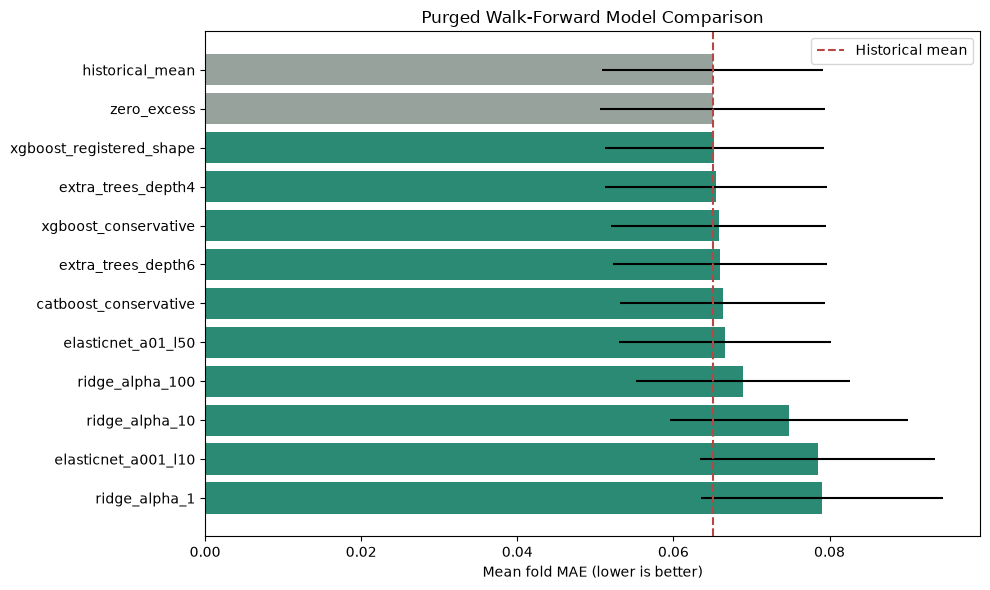

In [5]:
plot_frame = benchmark.summary.sort_values('mean_mae', ascending=True)
baseline_mae = float(
    plot_frame.loc[plot_frame.model == 'historical_mean', 'mean_mae'].iloc[0]
)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    plot_frame.model,
    plot_frame.mean_mae,
    xerr=plot_frame.std_mae,
    color=['#147d64' if not family.startswith('baseline_') else '#8c9893'
           for family in plot_frame.family],
    alpha=0.9,
)
ax.axvline(baseline_mae, color='#b54747', linestyle='--', label='Historical mean')
ax.set_xlabel('Mean fold MAE (lower is better)')
ax.set_title('Purged Walk-Forward Model Comparison')
ax.invert_yaxis()
ax.legend()
plt.tight_layout()

## Stability by Fold

In [6]:
benchmark.fold_metrics.pivot(
    index='model',
    columns='fold',
    values='mae',
).loc[benchmark.summary.model].style.format('{:.4f}')

fold,fold_01,fold_02,fold_03,fold_04
model,,,,
historical_mean,0.0462,0.0578,0.0731,0.0830
zero_excess,0.0460,0.0575,0.0731,0.0836
xgboost_registered_shape,0.0478,0.0566,0.0724,0.0842
extra_trees_depth4,0.0482,0.0558,0.0734,0.0843
xgboost_conservative,0.0499,0.0556,0.0733,0.0843
extra_trees_depth6,0.0493,0.0568,0.0739,0.0841
catboost_conservative,0.0499,0.0584,0.0729,0.0840
elasticnet_a01_l50,0.0497,0.0585,0.0733,0.0850
ridge_alpha_100,0.0541,0.0581,0.0752,0.0884


## Selection Decision

A walk-forward winner is only a candidate for a genuinely future holdout. It is never production-eligible from this notebook.

In [7]:
pd.Series(benchmark.selection, name='value').to_frame()

,value
selected_model,xgboost_registered_shape
selected_family,xgboost
selection_metric,lowest mean fold MAE among learned models
mean_mae,0.06524
historical_mean_mae,0.065011
absolute_mae_improvement,-0.000229
fold_wins_vs_historical_mean,2
fold_count,4
pooled_spearman_ic,0.081553
eligible_for_fresh_holdout,False
